Number of sentences: 10000

the dog is slow.
the dog watches the cat.
the cat sees the bird.
the child is old and eats the car.
the farmer is fast and chases the ball.
the teacher chases the dog.
the dog follows the cat near the house.
the cat visits the car.
the child is young.
the dog is happy.
the dog follows the fish on the street.
the boy helps the food on the street.
the dog is strong.
the boy is happy.
the teacher is small and likes the bird.
the bird sees the bird on the street.
the girl visits the book at the school.
the boy is strong and eats the car.
the farmer is slow and follows the food.
the dog is fast.
Vocabulary size: 56
Vocabulary: {'<PAD>': 0, '<UNK>': 1, '<BOS>': 2, '<EOS>': 3, 'the': 4, 'dog': 5, 'is': 6, 'slow': 7, '.': 8, 'watches': 9, 'cat': 10, 'sees': 11, 'bird': 12, 'child': 13, 'old': 14, 'and': 15, 'eats': 16, 'car': 17, 'farmer': 18, 'fast': 19, 'chases': 20, 'ball': 21, 'teacher': 22, 'follows': 23, 'near': 24, 'house': 25, 'visits': 26, 'young': 27, 'hap

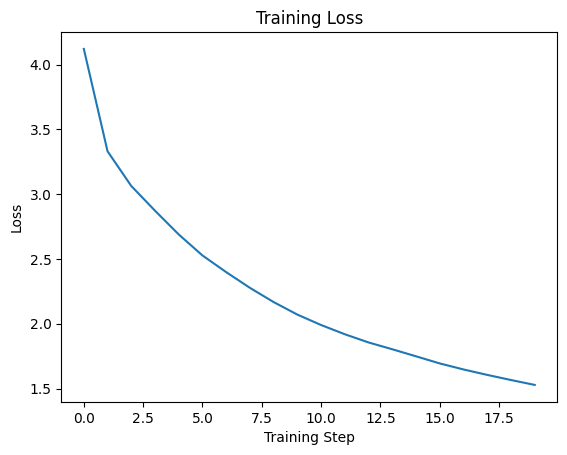

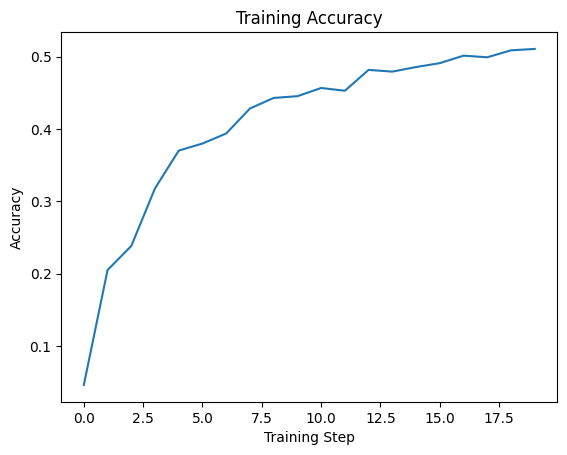

In [1]:
import random

random.seed(42)

subjects = [
    "the cat",
    "the dog",
    "the boy",
    "the girl",
    "the bird",
    "the teacher",
    "the student",
    "the robot",
    "the child",
    "the farmer",
]

verbs = [
    "likes",
    "sees",
    "finds",
    "eats",
    "chases",
    "helps",
    "follows",
    "visits",
    "watches",
    "carries",
]

objects = [
    "the ball",
    "the cat",
    "the dog",
    "the bird",
    "the fish",
    "the food",
    "the book",
    "the toy",
    "the car",
    "the tree",
]

adjectives = [
    "small",
    "big",
    "fast",
    "slow",
    "happy",
    "young",
    "old",
    "quiet",
    "strong",
    "kind",
]

locations = [
    "in the park",
    "at the school",
    "near the house",
    "in the garden",
    "by the river",
    "on the street",
]


def generate_sentence():
    subject = random.choice(subjects)
    verb = random.choice(verbs)
    obj = random.choice(objects)
    adjective = random.choice(adjectives)
    location = random.choice(locations)

    sentence_type = random.randint(1, 4)

    if sentence_type == 1:
        return f"{subject} {verb} {obj}."

    elif sentence_type == 2:
        return f"{subject} is {adjective}."

    elif sentence_type == 3:
        return f"{subject} {verb} {obj} {location}."

    else:
        return f"{subject} is {adjective} and {verb} {obj}."


# Generate corpus
num_sentences = 10000

corpus = [
    generate_sentence()
    for _ in range(num_sentences)
]

print("Number of sentences:", len(corpus))
print()
print("\n".join(corpus[:20]))

import re
from collections import Counter


# ============================================================
# 1. TOKENIZE EACH SENTENCE INTO WORDS
# ============================================================

def tokenize(text):
    # Lowercase
    text = text.lower()

    # Separate punctuation from words
    # "cat." -> "cat ."
    text = re.sub(r"([.,!?])", r" \1", text)

    # Split on whitespace
    tokens = text.split()

    return tokens


# ============================================================
# 2. BUILD VOCABULARY FROM YOUR CORPUS
# ============================================================

counter = Counter()

for sentence in corpus:
    tokens = tokenize(sentence)
    counter.update(tokens)


# ============================================================
# 3. SPECIAL TOKENS
# ============================================================

special_tokens = [
    "<PAD>",
    "<UNK>",
    "<BOS>",
    "<EOS>"
]


# ============================================================
# 4. CREATE TOKEN → ID MAPPING
# ============================================================

stoi = {}

for idx, token in enumerate(special_tokens):
    stoi[token] = idx


for token in counter:
    if token not in stoi:
        stoi[token] = len(stoi)


# ============================================================
# 5. CREATE ID → TOKEN MAPPING
# ============================================================

itos = {
    idx: token
    for token, idx in stoi.items()
}


# ============================================================
# 6. VOCABULARY SIZE
# ============================================================

vocab_size = len(stoi)

print("Vocabulary size:", vocab_size)
print("Vocabulary:", stoi)

import torch
import torch.nn as nn
import torch.nn.functional as F


# ============================================================
# 1. CONFIGURATION
# ============================================================

# TODO:
# Define small values for:
vocabulary_size = vocab_size
embedding_dimension = 128
number_of_heads = 4
number_of_transformer_layers = 4
sequence_length = 32
learning_rate = 0.001
num_training_steps = 20  # after confirming everything works will take it to 1000 steps
ff_hidden_dim = 512


# ============================================================
# 2. TOY DATASET
# ============================================================

# TODO:
# Create a very small text dataset yourself.
#
# Example idea:
# "I love cats"
# "I love dogs"
# "cats are cute"
# etc.
#
# You will need to decide:
# - vocabulary
# - token -> integer mapping
# - integer -> token mapping


# TODO:
# Write a function that takes text
# and converts it into token IDs.
#
def encode(text):
    tokens = tokenize(text)
    token_ids = [stoi.get(token, stoi["<UNK>"]) for token in tokens]

    return token_ids


# TODO:
# Write the reverse function.
#
def decode(token_ids):
    decoded_tokens = [itos[token] for token in token_ids]
    text = " ".join(decoded_tokens)

    return text



# ============================================================
# 3. CREATE TRAINING INPUT AND TARGET
# ============================================================

# TODO:
# For next-token prediction, create:
#
# input  = [token_1, token_2, token_3, ...]
# target = [token_2, token_3, token_4, ...]
#
# Remember:
# target is shifted one position to the left relative to input.

def create_training_data(corpus):
    input_ids = []
    target_ids = []

    pad_id = stoi["<PAD>"]

    for sentence in corpus:
        token_ids = encode(sentence)

        # Next-token prediction
        input_sequence = token_ids[:-1]
        target_sequence = token_ids[1:]

        # Make sure sequence isn't longer than our maximum length
        input_sequence = input_sequence[:sequence_length]
        target_sequence = target_sequence[:sequence_length]

        # Calculate how much padding is needed
        padding_needed = sequence_length - len(input_sequence)

        # Add padding
        input_sequence = input_sequence + [pad_id] * padding_needed
        target_sequence = target_sequence + [pad_id] * padding_needed

        input_ids.append(input_sequence)
        target_ids.append(target_sequence)

    return input_ids, target_ids


input_ids, target_ids = create_training_data(corpus)


# ============================================================
# 4. TOKEN EMBEDDING
# ============================================================

# TODO:
# Create token embedding.
#
# Hint:
# nn.Embedding(...)
#
# Input:
#     token IDs
#
# Output:
#     token representations of size d_model

def create_token_embedding(token_ids):
    token_embedding = nn.Embedding(vocabulary_size, embedding_dimension)

    x = token_embedding(token_ids)

    return x

input_tensor = torch.tensor(input_ids[0], dtype=torch.long)
create_token_embedding(input_tensor)

# ============================================================
# 5. POSITIONAL INFORMATION
# ============================================================

# TODO:
# Implement positional encoding/positional embeddings.
#
# You can initially use a learnable positional embedding:
#
# nn.Embedding(sequence_length, d_model)
#
# Then add:
#
# token_embedding + positional_embedding

def positional_embedding(sequence_length, embedding_dimension):

    # Positions: 0, 1, 2, ..., sequence_length - 1
    pos = torch.arange(sequence_length).unsqueeze(1)

    # i values: 0, 1, 2, ..., d_model/2 - 1
    i = torch.arange(embedding_dimension // 2)

    # Denominator from the formula
    denominator = 10000 ** (2 * i / embedding_dimension)

    # Every position combined with every i
    angles = pos / denominator

    # Sin goes into even dimensions
    pe_sin = torch.sin(angles)

    # Cos goes into odd dimensions
    pe_cos = torch.cos(angles)

    # Create final positional encoding matrix
    pe = torch.zeros(sequence_length, embedding_dimension)

    pe[:, 0::2] = pe_sin
    pe[:, 1::2] = pe_cos

    return pe


# ============================================================
# 6. SELF-ATTENTION
# ============================================================

class SelfAttention(nn.Module):

    def __init__(self, d_model, head_dim):
        super().__init__()

        # TODO:
        # Create the linear projections:
        #
        # W_Q
        # W_K
        # W_V
        #
        # You can use nn.Linear.

        self.head_dim = head_dim

        self.W_Q = nn.Linear(d_model, head_dim)
        self.W_K = nn.Linear(d_model, head_dim)
        self.W_V = nn.Linear(d_model, head_dim)


    def forward(self, x, padding_mask):

        # TODO:
        # 1. Calculate Q
        #
        Q = self.W_Q(x)


        # TODO:
        # 2. Calculate K
        #
        K = self.W_K(x)
        

        # TODO:
        # 3. Calculate V
        #
        V = self.W_V(x)
        

        # TODO:
        # 4. Calculate attention scores
        #
        # QK^T
        #
        # Remember to scale by sqrt(d_k).

        # attention_score = (Q @ K.T) / torch.sqrt(torch.tensor(self.head_dim, dtype=torch.float32))
        # attention_score = (Q @ K.T) / (self.head_dim ** 0.5)
        attention_score = (
            Q @ K.transpose(-2, -1)
        ) / (self.head_dim ** 0.5)

        # TODO:
        # 5. Create a causal mask.
        # ask gpt about it
        # A token should NOT be allowed
        # to look at future tokens.
        # Causal mask
        sequence_length = x.shape[0]

        causal_mask = torch.tril(
            torch.ones(sequence_length, sequence_length)
        )


        # Padding mask
        attention_score = (
            Q @ K.transpose(-2, -1)
        ) / (self.head_dim ** 0.5)


        # TODO:
        # 7. Apply softmax.
        #
        # This gives you the attention weights.

        attention_weights = F.softmax(attention_score, dim = -1)

        # TODO:
        # 8. Multiply attention weights by V.
        #
        # attention_weights @ V

        updated_token_representations = attention_weights @ V

        # TODO:
        # Return the updated token representations.

        return updated_token_representations


# ============================================================
# 7. MULTI-HEAD ATTENTION
# ============================================================

class MultiHeadAttention(nn.Module):

    def __init__(self, d_model, num_heads):
        super().__init__()

        # TODO:
        # Decide how you want to implement multiple heads.
        #
        # Option 1:
        # Create multiple SelfAttention objects.

        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.heads = nn.ModuleList([
            SelfAttention(d_model, self.head_dim)
            for _ in range(num_heads)
        ])

        self.W_O = nn.Linear(d_model, d_model)
        #
        # Option 2:
        # Create one large Q/K/V projection and reshape
        # into multiple heads.
        #
        # For learning purposes, Option 1 is easier to understand.


    def forward(self, x, padding_mask):

        # TODO:
        # Send x through every attention head.
        head_outputs = []

        for head in self.heads:
            output = head(x, padding_mask)
            head_outputs.append(output)

        # TODO:
        # Concatenate the outputs from all heads.
        concatenation = torch.cat(head_outputs, dim = -1)

        # TODO:
        # Apply the final output projection W_O.
        output = self.W_O(concatenation)


        # TODO:
        # Return multi-head attention output.
        return output


# ============================================================
# 8. FEED FORWARD NETWORK
# ============================================================

class FeedForward(nn.Module):

    def __init__(self, d_model, hidden_dim):
        super().__init__()

        # TODO:
        # Create:
        #
        # Linear 1:
        # d_model -> hidden_dim
        self.linear1 = nn.Linear(d_model, hidden_dim)
        #
        # Activation:
        # GELU or ReLU
        #
        # Linear 2:
        # hidden_dim -> d_model
        self.linear2 = nn.Linear(hidden_dim, d_model)


    def forward(self, x):

        # TODO:
        # Apply:
        #
        # Linear
        #     ↓
        # Activation
        #     ↓
        # Linear

        x = self.linear1(x)
        x = F.gelu(x)
        x = self.linear2(x)

        return x


# ============================================================
# 9. TRANSFORMER BLOCK
# ============================================================

class TransformerBlock(nn.Module):

    def __init__(self, d_model, num_heads, ff_hidden_dim):
        super().__init__()

        # TODO:
        # Create:
        #
        # MultiHeadAttention
        # FeedForward
        # LayerNorm(s)
        self.multihead_attention = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = FeedForward(d_model, ff_hidden_dim)
        self.layer_norm1 = nn.LayerNorm(d_model)
        self.layer_norm2 = nn.LayerNorm(d_model)


    def forward(self, x, padding_mask):

        # TODO:
        # Self-attention
        #
        attention_output = self.multihead_attention(x, padding_mask)


        # TODO:
        # Residual connection + normalization
        #
        x = x + attention_output
        x = self.layer_norm1(x)


        # TODO:
        # Feed Forward
        ff_output = self.feed_forward(x)


        # TODO:
        # Second residual connection + normalization
        x = x + ff_output
        output = self.layer_norm2(x)


        # TODO:
        # Return output

        return output


# ============================================================
# 10. COMPLETE MINI TRANSFORMER
# ============================================================

class MiniTransformer(nn.Module):

    def __init__(
        self,
        vocab_size,
        d_model,
        num_heads,
        num_layers,
        sequence_length,
        ff_hidden_dim
    ):
        super().__init__()

        # TODO:
        # Create token embedding.
        self.token_embedding = nn.Embedding(vocab_size, d_model)

        # TODO:
        # Create positional embedding.
        self.register_buffer(
            "positional_embedding",
            positional_embedding(sequence_length, d_model)
        )


        # TODO:
        # Create multiple TransformerBlocks.
        #
        # Hint:
        # nn.ModuleList(...)
        #
        # num_layers tells you how many blocks
        # should be stacked.
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads, ff_hidden_dim)
            for _ in range(num_layers)
            ])


        # TODO:
        # Create final LayerNorm if you want one.

        self.layer_norm = nn.LayerNorm(d_model)


        # TODO:
        # Create final linear layer:
        #
        # d_model -> vocab_size
        #
        # This produces LOGITS.

        self.linear = nn.Linear(d_model, vocab_size)


    def forward(self, input_ids):

        # -------------------------
        # Token embedding
        # -------------------------

        x = self.token_embedding(input_ids)

        # [32] → [32, 128]


        # -------------------------
        # Positional embedding
        # -------------------------

        positional_embedding = self.positional_embedding[
            :input_ids.shape[0]
        ]

        # [32, 128]

        x = x + positional_embedding

        # [32, 128]


        # -------------------------
        # Padding mask
        # -------------------------

        pad_id = stoi["<PAD>"]

        padding_mask = input_ids != pad_id

        # input_ids:
        # [32]
        #
        # padding_mask:
        # [32]


        # -------------------------
        # Transformer blocks
        # -------------------------

        for transformer_block in self.transformer_blocks:

            x = transformer_block(
                x,
                padding_mask
            )

            # [32, 128]


        # -------------------------
        # Final normalization
        # -------------------------

        x = self.layer_norm(x)

        # [32, 128]


        # -------------------------
        # Vocabulary logits
        # -------------------------

        logits = self.linear(x)

        # [32, vocabulary_size]

        return logits


# ============================================================
# 11. CREATE MODEL
# ============================================================

# TODO:
# Instantiate your MiniTransformer.

model = MiniTransformer(
    vocab_size=vocabulary_size,
    d_model=embedding_dimension,
    num_heads=number_of_heads,
    num_layers=number_of_transformer_layers,
    sequence_length=sequence_length,
    ff_hidden_dim=ff_hidden_dim
)
logits = model(input_tensor)


# ============================================================
# 12. LOSS FUNCTION
# ============================================================

# TODO:
# Use CrossEntropyLoss.
#
# Remember:
# model output = logits
# target = correct next token IDs

cross_entropy = nn.CrossEntropyLoss(
    ignore_index=stoi["<PAD>"]
)

target_tensor = torch.tensor(target_ids[0], dtype=torch.long)



# ============================================================
# 13. OPTIMIZER
# ============================================================

# TODO:
# Create an optimizer.
#
# Adam or AdamW would be a good choice.

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate
)

losses = []
accuracies = []

pad_id = stoi["<PAD>"]

for step in range(num_training_steps):

    model.train()

    input_tensor = torch.tensor(input_ids, dtype=torch.long)
    target_tensor = torch.tensor(target_ids, dtype=torch.long)

    # Forward pass
    logits = model(input_tensor)

    # Loss
    loss = cross_entropy(logits.transpose(1, 2), target_tensor)

    # Accuracy
    predictions = torch.argmax(logits, dim=-1)

    valid_positions = target_tensor != pad_id

    correct = (
        (predictions == target_tensor) &
        valid_positions
    )

    accuracy = correct.sum().float() / valid_positions.sum()

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Store metrics
    losses.append(loss.item())
    accuracies.append(accuracy.item())

    print(
        f"Step {step + 1}, "
        f"Loss: {loss.item():.4f}, "
        f"Accuracy: {accuracy.item() * 100:.2f}%"
    )

    import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

plt.plot(accuracies)
plt.xlabel("Training Step")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.show()